In [ ]:
import cv2
import json
import time
import torch
import random
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from PIL import Image
from transformers import Qwen2TokenizerFast, Qwen3ForCausalLM, AutoConfig

from diffusers.utils import load_image
from diffusers.schedulers import FlowMatchEulerDiscreteScheduler
from diffusers.models import AutoencoderKLFlux2, Flux2Transformer2DModel

from ctgmworkshop.flux_tools import *
from ctgmworkshop.image_tools import *

device = "cuda"
dtype = torch.bfloat16
plt.style.use("dark_background")

In [2]:
dtype = torch.bfloat16

text_encoder = Qwen3ForCausalLM.from_pretrained(
    "../../FLUX.2-klein-4B/text_encoder", local_files_only=True
).to(device)
tokenizer = Qwen2TokenizerFast.from_pretrained(
    "../../FLUX.2-klein-4B/tokenizer", local_files_only=True, device=device
)

scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(
    "../../FLUX.2-klein-4B/scheduler", device=device
)
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(
    device, dtype
)
transformer = Flux2Transformer2DModel.from_pretrained(
    "../../FLUX.2-klein-4B/transformer", device=device
).to(device, dtype)

vae_mean, vae_std = get_latents_mean_std(vae)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [3]:
prompts = ["Turn this into anime art", "Turn this into art in style of Kandinsky"]


def build_random_prompt():
    return random.choice(prompts)

In [4]:
cap = cv2.VideoCapture("../../local_samples/walking.mp4")

In [5]:
def get_next_frame_pair(cap, skip: int = 20, distance: int = 20):

    for _ in range(skip):
        ret, frame = cap.read()
        if not ret:
            raise StopIteration("End of sequence")

    frame_A = frame

    for _ in range(distance):
        ret, frame = cap.read()
        if not ret:
            raise StopIteration("End of sequence")
    frame_B = frame

    return frame_A, frame_B


In [6]:
height = 512
width = 960

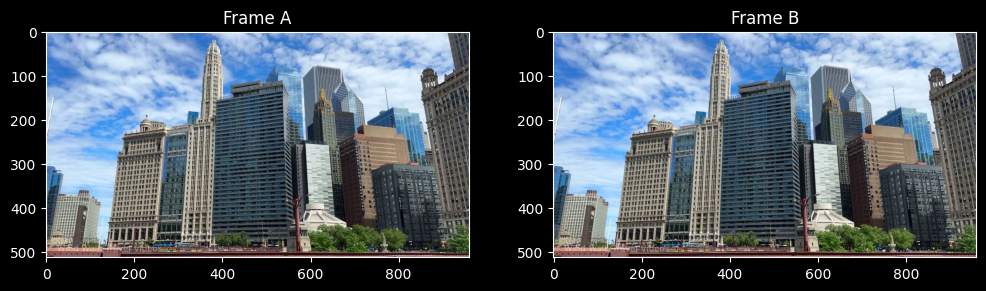

In [7]:
frame_A, frame_B = get_next_frame_pair(cap, skip=200, distance=100)


frame_A = resize_np(cv2_to_np(frame_A), height=height, width=width)
frame_B = resize_np(cv2_to_np(frame_B), height=height, width=width)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Frame A")
plt.imshow(frame_A)
plt.subplot(1, 2, 2)
plt.title("Frame B")
plt.imshow(frame_B)
plt.show()

In [8]:
# cap.release()

In [17]:
@torch.no_grad()
def process_frame(frame, seed, prompt):
    num_inference_steps = 2

    frame = norm_image(resize_torch(cv2_to_torch(frame), height=height, width=width))

    image_latents, image_latent_ids = prepare_image_latents(
        images=[frame], vae=vae, batch_size=1, device=device, dtype=dtype
    )

    cond_latents = unpack_latents_with_ids(image_latents, image_latent_ids)
    cond_latents = unpatchify_latents(cond_latents)

    # cond_latents -> return

    prompt_embeds, text_ids = encode_prompt(
        prompt=prompt,
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        device=device,
        num_images_per_prompt=1,
        max_sequence_length=512,
        text_encoder_out_layers=(9, 18, 27),
    )

    generator = torch.Generator(device="cuda").manual_seed(seed)

    latents, latent_ids = prepare_latents(
        batch_size=1,
        num_latents_channels=32,
        height=height,
        width=width,
        dtype=dtype,
        device=device,
        generator=generator,
    )

    sigmas = np.linspace(1.0, 1 / num_inference_steps, num_inference_steps)

    image_seq_len = latents.shape[1]

    mu = compute_empirical_mu(
        image_seq_len=image_seq_len, num_steps=num_inference_steps
    )

    timesteps, num_inference_steps = retrieve_timesteps(
        scheduler,
        num_inference_steps,
        device,
        sigmas=sigmas,
        mu=mu,
    )

    scheduler.set_begin_index(0)

    init_latents = latents.clone()
    init_latents = unpack_latents_with_ids(init_latents, latent_ids)
    init_latents = unpatchify_latents(init_latents)

    # init_latents -> return

    for i, t in enumerate(timesteps):
        timestep = t.expand(latents.shape[0]).to(latents.dtype)

        latent_model_input = latents.to(transformer.dtype)
        latent_image_ids = latent_ids

        noise_pred = transformer(
            hidden_states=torch.cat(
                [latent_model_input, image_latents], dim=1
            ),  # (B, image_seq_len, C)
            timestep=timestep / 1000,
            guidance=None,
            encoder_hidden_states=prompt_embeds,
            txt_ids=text_ids,  # B, text_seq_len, 4
            img_ids=torch.cat(
                [latent_image_ids, image_latent_ids], dim=1
            ),  # B, image_seq_len, 4
            return_dict=False,
        )[0]

        noise_pred = noise_pred[:, : latents.size(1), :]

        # compute the previous noisy sample x_t -> x_t-1
        latents = scheduler.step(noise_pred, t, latents, return_dict=False)[0]

    vae_scale_factor = 8

    latent_height = 2 * (int(height) // (vae_scale_factor * 2))
    latent_width = 2 * (int(width) // (vae_scale_factor * 2))

    latents = unpack_latents_with_ids(
        latents, latent_ids, latent_height // 2, latent_width // 2
    )

    final_latents = unpatchify_latents(latents)

    # final_latents -> return

    return cond_latents, init_latents, final_latents


@torch.no_grad()
def process_pair(frame_A, frame_B):

    seed = random.randint(0, 1000000)
    prompt = build_random_prompt()

    cond_latents_A, init_latents_A, final_latents_A = process_frame(
        frame_A, seed, prompt
    )
    cond_latents_B, init_latents_B, final_latents_B = process_frame(
        frame_B, seed, prompt
    )

    # init_latents_A and init_latents_B are same
    return (
        cond_latents_A,
        cond_latents_B,
        final_latents_A,
        final_latents_B,
        init_latents_A,
    )


In [27]:
frame_A, frame_B = get_next_frame_pair(cap, skip=200, distance=100)

(
    cond_latents_A,
    cond_latents_B,
    final_latents_A,
    final_latents_B,
    init_latents_A,
) = process_pair(frame_A, frame_B)

Text(0.5, 1.0, 'Final Image B')

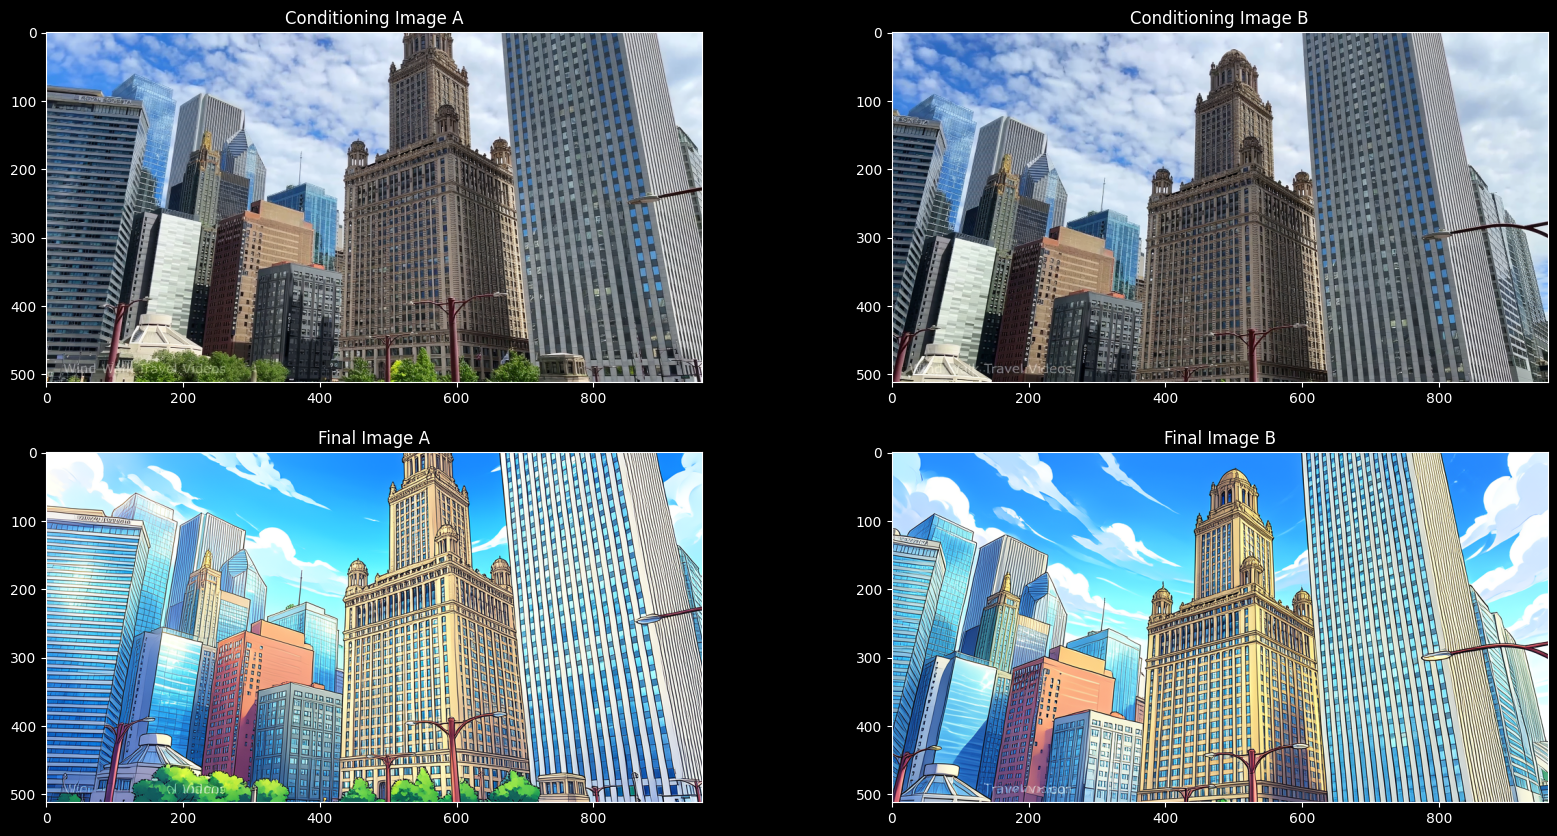

In [ ]:
def process_latent(latent):
    img = denorm_unpatchified_latents(latent, mean=vae_mean, std=vae_std)
    img = decode_latents(img, vae)
    img = denorm_image(img)
    return torch_to_np(img)


latents = [cond_latents_A, cond_latents_B, final_latents_A, final_latents_B]
cond_image_A, cond_image_B, final_image_A, final_image_B = map(process_latent, latents)


fig, ax = plt.subplots(2, 2, figsize=(20, 10))
ax[0, 0].imshow(cond_image_A)
ax[0, 0].set_title("Conditioning Image A")
ax[0, 1].imshow(cond_image_B)
ax[0, 1].set_title("Conditioning Image B")
ax[1, 0].imshow(final_image_A)
ax[1, 0].set_title("Final Image A")
ax[1, 1].imshow(final_image_B)
ax[1, 1].set_title("Final Image B")

In [ ]:
num_blocks = 1000

latent_height = height // 8
latent_width = width // 8


all_init_latents = torch.zeros(
    (num_blocks, 32, latent_height, latent_width),
    dtype=torch.float16,
)

all_cond_latents_A = all_init_latents.clone()
all_cond_latents_B = all_init_latents.clone()
all_final_latents_A = all_init_latents.clone()
all_final_latents_B = all_init_latents.clone()

In [63]:
for i in tqdm(range(num_blocks)):
    try:
        frame_A, frame_B = get_next_frame_pair(cap, skip=1, distance=25)
    except StopIteration:
        print("End of video reached, restarting...")
        cap.release()
        cap = cv2.VideoCapture("../../local_samples/walking.mp4")
        frame_A, frame_B = get_next_frame_pair(cap, skip=1, distance=25)

    (
        cond_latents_A,
        cond_latents_B,
        final_latents_A,
        final_latents_B,
        init_latents_A,
    ) = process_pair(frame_A, frame_B)

    all_init_latents[i] = init_latents_A.squeeze(0).cpu()
    all_cond_latents_A[i] = cond_latents_A.squeeze(0).cpu()
    all_cond_latents_B[i] = cond_latents_B.squeeze(0).cpu()
    all_final_latents_A[i] = final_latents_A.squeeze(0).cpu()
    all_final_latents_B[i] = final_latents_B.squeeze(0).cpu()

100%|██████████| 1000/1000 [27:28<00:00,  1.65s/it]


In [ ]:
torch.save(
    all_init_latents, "../../precomputes/flow_refractor/test-1/all_init_latents.pt"
)
torch.save(
    all_cond_latents_A, "../../precomputes/flow_refractor/test-1/all_cond_latents_A.pt"
)
torch.save(
    all_cond_latents_B, "../../precomputes/flow_refractor/test-1/all_cond_latents_B.pt"
)
torch.save(
    all_final_latents_A,
    "../../precomputes/flow_refractor/test-1/all_final_latents_A.pt",
)
torch.save(
    all_final_latents_B,
    "../../precomputes/flow_refractor/test-1/all_final_latents_B.pt",
)